# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Bima Setia Sugiharto
- **Email:** bimasetia182@gmail.com
- **ID Dicoding:** bimasugiharto

## Menentukan Pertanyaan Bisnis

### Pertanyaan Bisnis

**Pertanyaan 1:**

Berapa rata-rata selisih hari keterlambatan pengiriman untuk setiap tingkat *review_score* pada periode **September 2016 – Oktober 2018**, dan **5 negara bagian mana** yang memiliki rata-rata durasi pengiriman terlama atau di atas 20 hari?

- **Specific:** Fokus pada korelasi antara keterlambatan pengiriman terhadap skor review pelanggan, serta identifikasi wilayah dengan performa terburuk.
- **Measurable:** Mengukur rata-rata selisih hari dan rata-rata durasi pengiriman per negara bagian dalam satuan hari.
- **Action-Oriented:** Hasil analisis dapat digunakan untuk memprioritaskan perbaikan logistik di wilayah bermasalah dan mengkalibrasi ulang estimasi waktu pengiriman.
- **Relevant:** Kepuasan pelanggan langsung berdampak pada reputasi dan retensi di platform e-commerce.
- **Time-bound:** Dibatasi pada periode September 2016 – Oktober 2018.

**Pertanyaan 2:**

Dari **15 kategori produk** dengan volume penjualan tertinggi selama periode **September 2016 – Oktober 2018**, kategori mana saja yang memiliki rata-rata skor kepuasan pelanggan **di bawah 4.0** dari skala 5.0?

- **Specific:** Fokus pada kategori produk terlaris yang justru memiliki tingkat kepuasan rendah.
- **Measurable:** Menggunakan metrik jumlah order dan rata-rata review_score per kategori.
- **Action-Oriented:** Dengan mengetahui kategori mana yang bermasalah, tim dapat menerapkan quality control khusus dan perbaikan packaging.
- **Relevant:** Kategori dengan volume tinggi namun rating rendah berpotensi menurunkan reputasi keseluruhan platform.
- **Time-bound:** Dibatasi pada periode September 2016 - Oktober 2018.


## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import folium

## Data Wrangling

### Gathering Data

Pada tahap ini, kita akan memuat seluruh 9 dataset dari E-Commerce Public Dataset ke dalam DataFrame. Dataset ini mencakup:
1. **customers_dataset** : Data pelanggan
2. **geolocation_dataset** : Data koordinat geografis per kode pos
3. **order_items_dataset** : Detail item dalam setiap pesanan
4. **order_payments_dataset** : Informasi pembayaran
5. **order_reviews_dataset** : Review/ulasan pelanggan
6. **orders_dataset** : Data utama pesanan
7. **product_category_name_translation** : Terjemahan nama kategori produk
8. **products_dataset** : Data produk
9. **sellers_dataset** : Data penjual

In [2]:
cus_df = pd.read_csv(os.path.join('Data', 'customers_dataset.csv'))
cus_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [3]:
geo_df = pd.read_csv(os.path.join('Data', 'geolocation_dataset.csv'))
geo_df.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [4]:
items_df = pd.read_csv(os.path.join('Data', 'order_items_dataset.csv'))
items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [5]:
pay_df = pd.read_csv(os.path.join('Data', 'order_payments_dataset.csv'))
pay_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [6]:
reviews_df = pd.read_csv(os.path.join('Data', 'order_reviews_dataset.csv'))
reviews_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [7]:
order_df = pd.read_csv(os.path.join('Data', 'orders_dataset.csv'))
order_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [8]:
category_df = pd.read_csv(os.path.join('Data', 'product_category_name_translation.csv'))
category_df.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [9]:
product_df = pd.read_csv(os.path.join('Data', 'products_dataset.csv'))
product_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [10]:
seller_df = pd.read_csv(os.path.join('Data', 'sellers_dataset.csv'))
seller_df.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


### **Insight:**
- Data diatas berisi sebuah rekaman lengkap dari sebuah bisnis marketplace yang menghubungkan pembeli dan penjual di wilayah geografis yang luas yang memiliki fokus utama pada efisiensi pengiriman dan kepuasan pelanggan.
- Data diatas memiliki variasi data yang sangat banyak yang dimana bermacam macam kota, wilayah serta memiliki berbagai macam jenis produk dan tingkat kepuasan pelanggan.

### Assessing Data

Pada tahap ini, kita akan menilai kualitas dari setiap dataset yang telah dimuat. Fokus penilaian meliputi:
- **Missing Values**. Apakah ada data yang kosong/null?
- **Duplicate Data**. Apakah ada baris yang terduplikasi?
- **Data Types**. Apakah tipe data sudah sesuai (misal: tanggal sebagai datetime)?
- **Invalid/Inconsistent Values**. Apakah ada nilai yang tidak konsisten?

Setelah identifikasi masalah, kita akan mendefinisikan solusi yang akan diterapkan pada tahap Cleaning Data.

#### Menilai `cus_df`

In [11]:
cus_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [12]:
print("Jumlah duplikasi: ", cus_df.duplicated().sum())

Jumlah duplikasi:  0


In [13]:
cus_df.describe()

,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


#### Menilai `geo_df`

In [14]:
geo_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


In [15]:
print("Jumlah duplikasi: ", geo_df.duplicated().sum())
geo_df.describe()

Jumlah duplikasi:  261831


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
count,1.000163e+06,1.000163e+06,1.000163e+06
mean,3.657417e+04,-2.117615e+01,-4.639054e+01
std,3.054934e+04,5.715866e+00,4.269748e+00
min,1.001000e+03,-3.660537e+01,-1.014668e+02
25%,1.107500e+04,-2.360355e+01,-4.857317e+01
50%,2.653000e+04,-2.291938e+01,-4.663788e+01
75%,6.350400e+04,-1.997962e+01,-4.376771e+01
max,9.999000e+04,4.506593e+01,1.211054e+02


#### Menilai `items_df`

In [16]:
items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [17]:
print("Jumlah duplikasi: ", items_df.duplicated().sum())
items_df.describe()

Jumlah duplikasi:  0


,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


#### Menilai `pay_df`

In [18]:
pay_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [19]:
print("jumlah duplikasi: ", pay_df.duplicated().sum())
pay_df.describe()

jumlah duplikasi:  0


,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


#### Menilai `reviews_df`

In [20]:
reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [21]:
reviews_df.isna().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [22]:
print("jumlah duplikasi: ", reviews_df.duplicated().sum())
reviews_df.describe()

jumlah duplikasi:  0


,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


#### Menilai `order_df`

In [23]:
order_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [24]:
order_df.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [25]:
print("jumlah duplikasi: ", order_df.duplicated().sum())
order_df.describe()

jumlah duplikasi:  0


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-04-11 10:48:14,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-08 23:38:46,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


#### Menilai `category_df`

In [26]:
category_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [27]:
print("jumlah duplikasi: ", category_df.duplicated().sum())
category_df.describe()

jumlah duplikasi:  0


,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1


#### Menilai `product_df`

In [28]:
product_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [29]:
product_df.isna().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [30]:
print("jumlah duplikasi: ", product_df.duplicated().sum())
product_df.describe()

jumlah duplikasi:  0


,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


#### Menilai `seller_df`

In [31]:
seller_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [32]:
print("jumlah duplikasi: ", seller_df.duplicated().sum())
seller_df.describe()

jumlah duplikasi:  0


,seller_zip_code_prefix
count,3095.000000
mean,32291.059451
std,32713.453830
min,1001.000000
25%,7093.500000
50%,14940.000000
75%,64552.500000
max,99730.000000


### **Insight:**
- Setelah melakukan penilaian dari keseluruhan dataset ditemukan ada data yang memiliki nilai yang duplikasinya tinggi pada dataset geo_df atau geolocation_dataset.
- Ditemukan juga pada dataset pada reviews_df (order_reviews_dataset), order_df(orders_dataset), dan product_df(products_dataset) memiliki banyak nilai yang kosong yang dimana pada data tersebut harusnya menjadi jantung pada keseluruhan data penjualan e-commerce ini.

### Cleaning Data

Berdasarkan hasil *Assessing Data*, berikut adalah tindakan pembersihan yang akan dilakukan:
1. **geo_df**: Menghapus data duplikat yang sangat banyak
2. **reviews_df**: Mengisi missing values di kolom `review_comment_title` dan `review_comment_message`
3. **order_df**: Memfilter hanya pesanan berstatus `delivered` dan menghapus missing values, serta mengonversi kolom tanggal ke format datetime
4. **product_df**: Menghapus baris dengan missing values
5. **Normalisasi**: Menyeragamkan penulisan nama kota dan memperbaiki tipe data

#### Cleaning `geo_df`

In [33]:
geo_df.isna().sum()

geolocation_zip_code_prefix    0
geolocation_lat                0
geolocation_lng                0
geolocation_city               0
geolocation_state              0
dtype: int64

In [34]:
geo_df.duplicated().sum()

np.int64(261831)

In [35]:
geo_df = geo_df.drop_duplicates()
geo_df.duplicated().sum()

np.int64(0)

#### Cleaning `reviews_df`

In [36]:
reviews_df.isna().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [37]:
reviews_df['review_comment_message'].fillna("No Comment", inplace=True)
reviews_df['review_comment_title'].fillna("No Title", inplace=True)

C:\Users\USER040824\AppData\Local\Temp\ipykernel_4212\3399372532.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  reviews_df['review_comment_message'].fillna("No Comment", inplace=True)
C:\Users\USER040824\AppData\Local\Temp\ipykernel_4212\3399372532.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values alw

In [38]:
reviews_df.isna().sum()

review_id                  0
order_id                   0
review_score               0
review_comment_title       0
review_comment_message     0
review_creation_date       0
review_answer_timestamp    0
dtype: int64

In [39]:
reviews_df.duplicated().sum()

np.int64(0)

#### Cleaning `order_df`

In [40]:
order_df.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [41]:
order_df = order_df[order_df['order_status'] == 'delivered']
order_df = order_df.dropna()

In [42]:
order_df.isna().sum()

order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
dtype: int64

In [43]:
order_df.duplicated().sum()

np.int64(0)

In [44]:
date_cols = ['order_purchase_timestamp', 'order_delivered_customer_date', 'order_estimated_delivery_date']
for col in date_cols:
    order_df[col] = pd.to_datetime(order_df[col])

#### Cleaning `product_df`

In [45]:
product_df.isna().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [46]:
product_df = product_df.dropna()
product_df.isna().sum()

product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64

In [47]:
product_df.duplicated().sum()

np.int64(0)

#### Normalisasi nama kota

In [48]:
cus_df

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS


In [49]:
seller_df

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP
...,...,...,...,...
3090,98dddbc4601dd4443ca174359b237166,87111,sarandi,PR
3091,f8201cab383e484733266d1906e2fdfa,88137,palhoca,SC
3092,74871d19219c7d518d0090283e03c137,4650,sao paulo,SP
3093,e603cf3fec55f8697c9059638d6c8eb5,96080,pelotas,RS


In [50]:
geo_df

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP
...,...,...,...,...,...
1000155,99965,-28.180655,-52.034367,agua santa,RS
1000156,99950,-28.072188,-52.011272,tapejara,RS
1000157,99950,-28.068864,-52.012964,tapejara,RS
1000158,99950,-28.068639,-52.010705,tapejara,RS


In [51]:
cols = ['customer_city', 'seller_city', 'geolocation_city']
datasets = [cus_df, seller_df, geo_df]

for df in datasets:
    col_name = [c for c in df.columns if 'city' in c][0] 
    df[col_name] = df[col_name].str.lower().str.replace(r'[^\w\s]', '', regex=True)

#### Normalisasi tipe data

In [52]:
items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [53]:
items_df['shipping_limit_date'] = pd.to_datetime(items_df['shipping_limit_date'])
items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  object        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  object        
 3   seller_id            112650 non-null  object        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB


### **Insight:**
- Setelah dilakukan proses cleaning dan normaliasi, didapatkan lah geo_df yang bersih dari nilai yang duplikat.
- Mengisi nilai null dari reviews df pada kolom review_comment_title dan review_comment_message dengan nilai no title dan no comment.
- Pada data order_df menimpan yang order_status `delivered` dan menghapus lainnya serta mengganti format menjadi datetime pada kolom `order_purchase_timestamp`, `order_delivered_customer_date`, `order_estimated_delivery_date`.
- Pada product_df menghapus semua data yang kosong.
- terakhir pada normalisasi nama kota agar konsisten dan tidak bertumpuk serta mengganti tipe data item_df menjadi datetime.

## Exploratory Data Analysis (EDA)

Pada tahap ini, kita akan melakukan eksplorasi awal terhadap data yang sudah dibersihkan untuk menemukan pola, anomali, dan insight awal. Eksplorasi dilakukan pada setiap dataset utama sebelum menjawab pertanyaan bisnis secara mendalam di tahap Visualization & Explanatory Analysis.


### Explore `order_df`

In [54]:
order_df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15


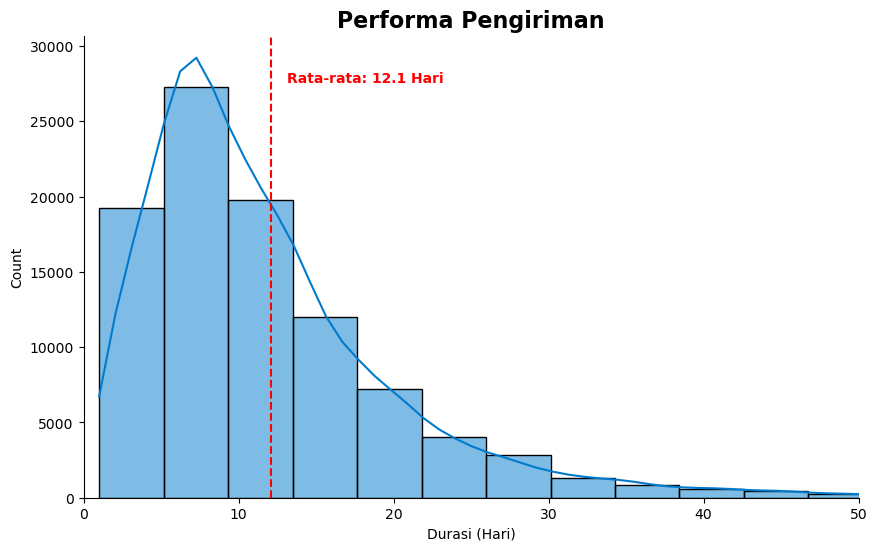

In [55]:
order_df['delivery_days'] = (order_df['order_delivered_customer_date'] - order_df['order_purchase_timestamp']).dt.days
df_clean = order_df.query("delivery_days > 0")

plt.figure(figsize=(10, 6))
sns.histplot(data=df_clean, x='delivery_days', kde=True, bins=50, color="#007ACC")

mean_val = df_clean['delivery_days'].mean()
plt.axvline(mean_val, color='red', linestyle='--')
plt.text(mean_val + 1, plt.ylim()[1]*0.9, f'Rata-rata: {mean_val:.1f} Hari', color='red', fontweight='bold')

plt.title('Performa Pengiriman', fontsize=16, fontweight='bold')
plt.xlabel('Durasi (Hari)')
plt.xlim(0, 50)
sns.despine()

plt.show()

### Explore `items_df`

In [56]:
items_df

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72


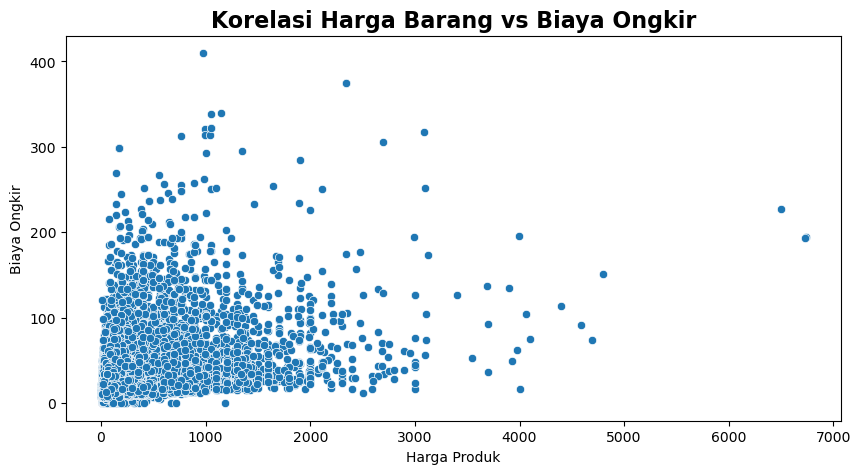

In [57]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=items_df, x='price', y='freight_value', alpha=1)
plt.title('Korelasi Harga Barang vs Biaya Ongkir', fontsize=16, fontweight='bold')
plt.xlabel('Harga Produk')
plt.ylabel('Biaya Ongkir')
plt.show()

### Explore `pay_df`

In [58]:
pay_df

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
...,...,...,...,...,...
103881,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31
103882,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80
103883,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77
103884,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54


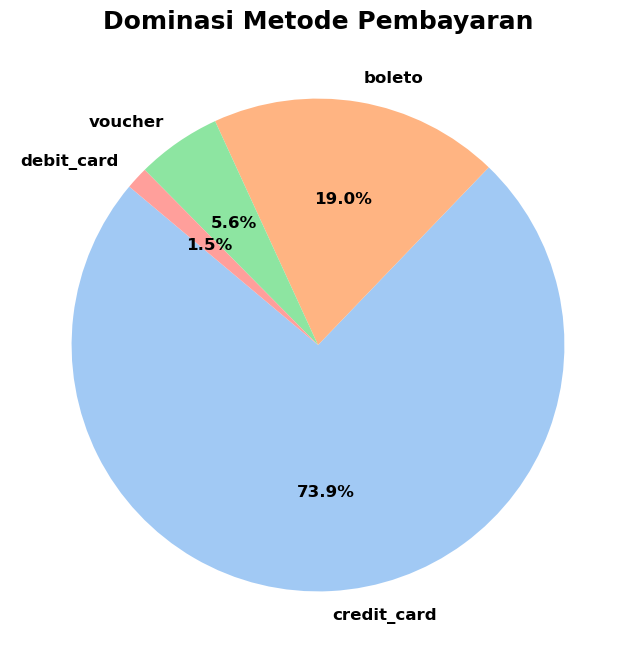

In [59]:
data_payment = pay_df.query("payment_type != 'not_defined'")['payment_type'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(data_payment, labels=data_payment.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'), startangle=140, textprops={'fontsize': 12, 'fontweight': 'bold'})
plt.title('Dominasi Metode Pembayaran', fontsize=18, fontweight='bold')
plt.show()

### Explore `reviews_df`

C:\Users\USER040824\AppData\Local\Temp\ipykernel_4212\2524299712.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=reviews_df, x='review_score', palette='viridis')


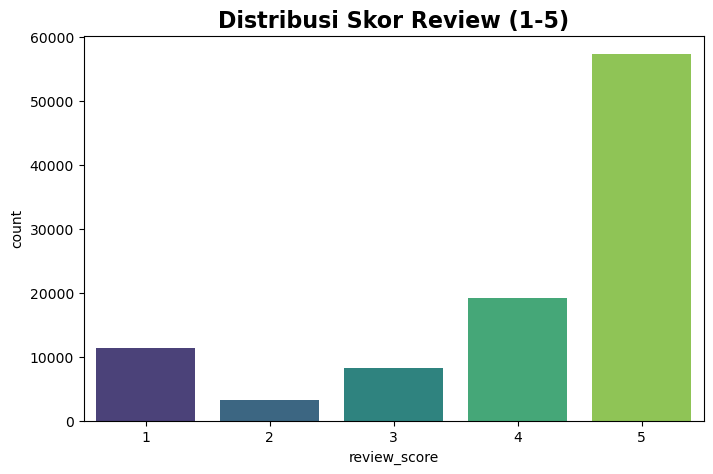

In [60]:
plt.figure(figsize=(8, 5))
sns.countplot(data=reviews_df, x='review_score', palette='viridis')
plt.title('Distribusi Skor Review (1-5)', fontsize=16, fontweight='bold')
plt.show()

### **Insight:**
- Pada visualisasi pertama kurva condong ke kiri, artinya mayoritas pengiriman cepat. Namun, adanya "ekor panjang" ke kanan (outlier > 30-50 hari) menunjukkan inkonsistensi pengiriman.
- Pada visualisasi kedua terdapat klaster barang "Toxic" di kiri atas grafik Harga Murah < 50 BRL, tapi Ongkir > 50 BRL
- Pada visualisasi pay_df Kartu kredit mendominasi mutlak 73.9%, diikuti oleh Boleto 19%.
- Pada visualisasi review_df data cenderung terpolarisasi. Banyak Bintang 5 tapi Bintang 1 juga cukup signifikan, sementara Bintang 3 (netral) sedikit dibandingkan bintang 1.

## Visualization & Explanatory Analysis

Pada tahap ini, kita akan membuat visualisasi data yang secara langsung menjawab kedua pertanyaan bisnis yang telah didefinisikan. Setiap visualisasi dirancang dengan menerapkan prinsip desain dan integritas data.


### Pertanyaan 1:

In [61]:
order_review = pd.merge(order_df, reviews_df, on='order_id')

full_data = pd.merge(order_review, cus_df, on='customer_id')
full_data['order_delivered_customer_date'] = pd.to_datetime(full_data['order_delivered_customer_date'])
full_data['order_estimated_delivery_date'] = pd.to_datetime(full_data['order_estimated_delivery_date'])
full_data['order_purchase_timestamp'] = pd.to_datetime(full_data['order_purchase_timestamp'])
full_data['delivery_delta'] = (full_data['order_delivered_customer_date'] - full_data['order_estimated_delivery_date']).dt.days
full_data['delivery_duration'] = (full_data['order_delivered_customer_date'] - full_data['order_purchase_timestamp']).dt.days
full_data = full_data.dropna(subset=['delivery_delta', 'review_score'])

C:\Users\USER040824\AppData\Local\Temp\ipykernel_4212\1061184721.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=full_data, x='review_score', y='delivery_delta', palette='RdYlGn', ax=ax1, showfliers=False)
C:\Users\USER040824\AppData\Local\Temp\ipykernel_4212\1061184721.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_performance, x='delivery_duration', y='customer_state', palette='flare', ax=ax2)


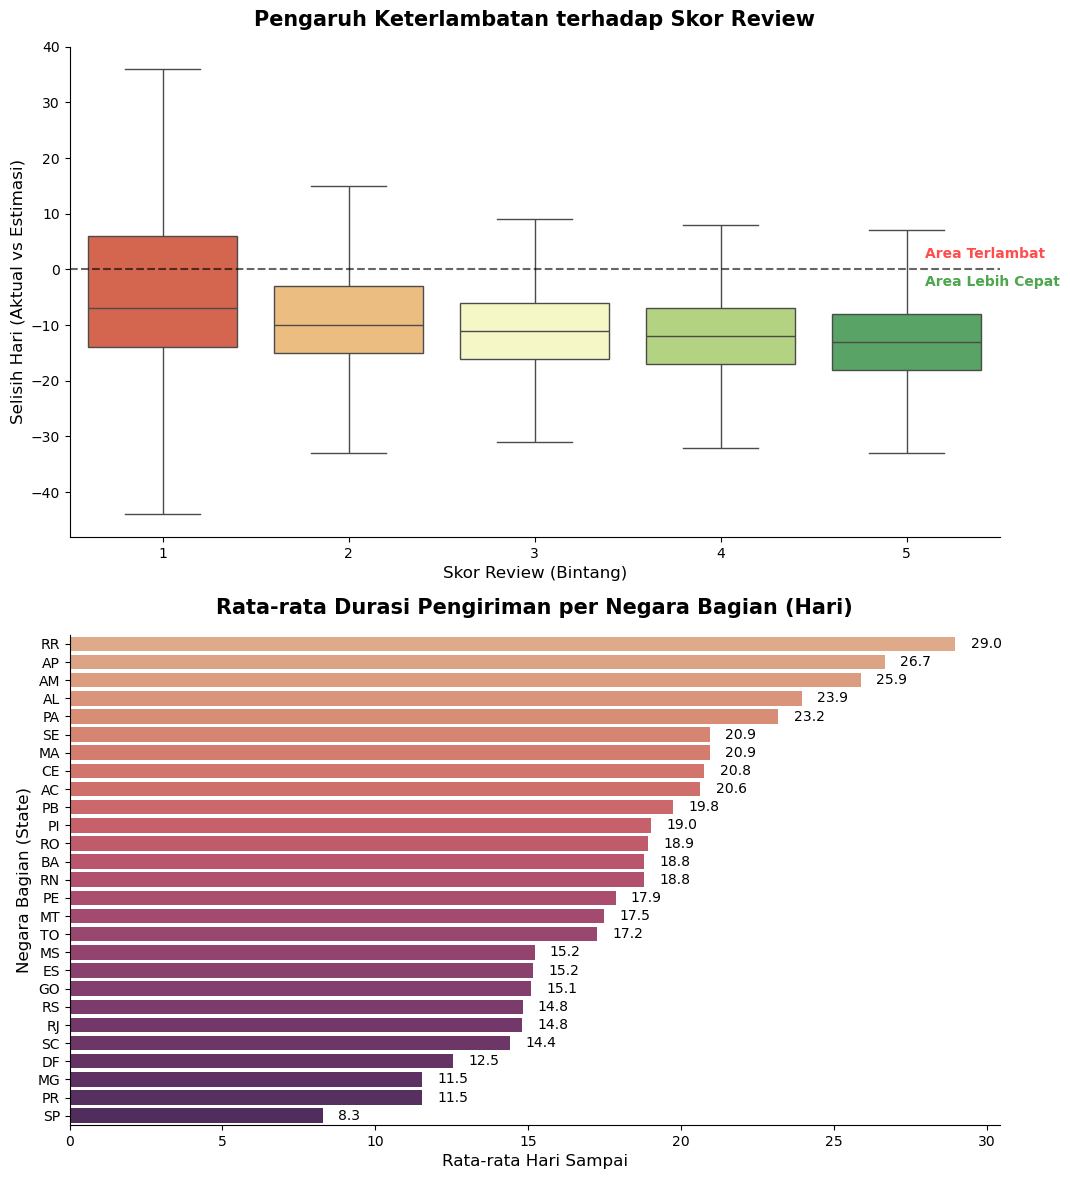

In [62]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 14))
plt.subplots_adjust(hspace=0.2)
sns.boxplot(data=full_data, x='review_score', y='delivery_delta', palette='RdYlGn', ax=ax1, showfliers=False)
ax1.axhline(0, color='black', linestyle='--', alpha=0.6)

ax1.set_title('Pengaruh Keterlambatan terhadap Skor Review', fontsize=15, fontweight='bold', pad=15)
ax1.set_xlabel('Skor Review (Bintang)', fontsize=12)
ax1.set_ylabel('Selisih Hari (Aktual vs Estimasi)', fontsize=12)
ax1.text(4.1, 2, 'Area Terlambat', color='red', fontweight='bold', alpha=0.7)
ax1.text(4.1, -3, 'Area Lebih Cepat', color='green', fontweight='bold', alpha=0.7)

state_performance = full_data.groupby('customer_state')['delivery_duration'].mean().sort_values(ascending=False).reset_index()

sns.barplot(data=state_performance, x='delivery_duration', y='customer_state', palette='flare', ax=ax2)
ax2.set_title('Rata-rata Durasi Pengiriman per Negara Bagian (Hari)', fontsize=15, fontweight='bold', pad=15)
ax2.set_xlabel('Rata-rata Hari Sampai', fontsize=12)
ax2.set_ylabel('Negara Bagian (State)', fontsize=12)

for i, v in enumerate(state_performance['delivery_duration']):
    ax2.text(v + 0.5, i, f'{v:.1f}', va='center', fontsize=10)

sns.despine()
plt.show()

### **Insight:**

1. Analisis Korelasi Waktu Pengiriman vs. Kepuasan Pelanggan

Visualisasi menggunakan Boxplot menunjukkan hubungan antara Delivery Delta selisih hari antara kedatangan aktual dengan estimasi terhadap Review Score.
- Terdapat pola yang sangat jelas di mana skor review rendah (Bintang 1 & 2) memiliki distribusi keterlambatan yang jauh lebih tinggi.
- Pada Bintang 1, median data berada di atas garis 0. Artinya, lebih dari 50% pelanggan yang memberikan Bintang 1 mengalami keterlambatan dari tanggal estimasi yang dijanjikan.
- Sebaliknya, pada Bintang 5, hampir seluruh kotak berada di bawah garis 0. Ini menunjukkan bahwa pelanggan sangat mengapresiasi jika barang sampai lebih cepat dari estimasi, yang secara signifikan meningkatkan peluang mendapatkan rating sempurna.
- Kepuasan pelanggan tidak hanya ditentukan oleh berapa lama barang sampai, tetapi oleh apakah kita menepati janji yang diberikan saat checkout.

2. Analisis Geografis Performa Pengiriman per Wilayah

Visualisasi Bar Chart menunjukkan rata-rata durasi pengiriman berdasarkan negara bagian pelanggan.
- Terjadi perbedaan performa yang sangat kontras antara wilayah pusat ekonomi dengan wilayah terpencil.
- Negara bagian di wilayah Utara dan Timur Laut memiliki performa terburuk. RR (Roraima), AP (Amapa), dan AM (Amazonas) mencatatkan waktu pengiriman rata-rata tertinggi, seringkali melebihi 25–30 hari.
- SP (Sao Paulo) dan wilayah selatan lainnya memiliki performa tercepat dengan rata-rata di bawah 10-12 hari, karena kedekatan dengan pusat distribusi dan infrastruktur yang lebih maju.

### Pertanyaan 2:

C:\Users\USER040824\AppData\Local\Temp\ipykernel_4212\3570170895.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


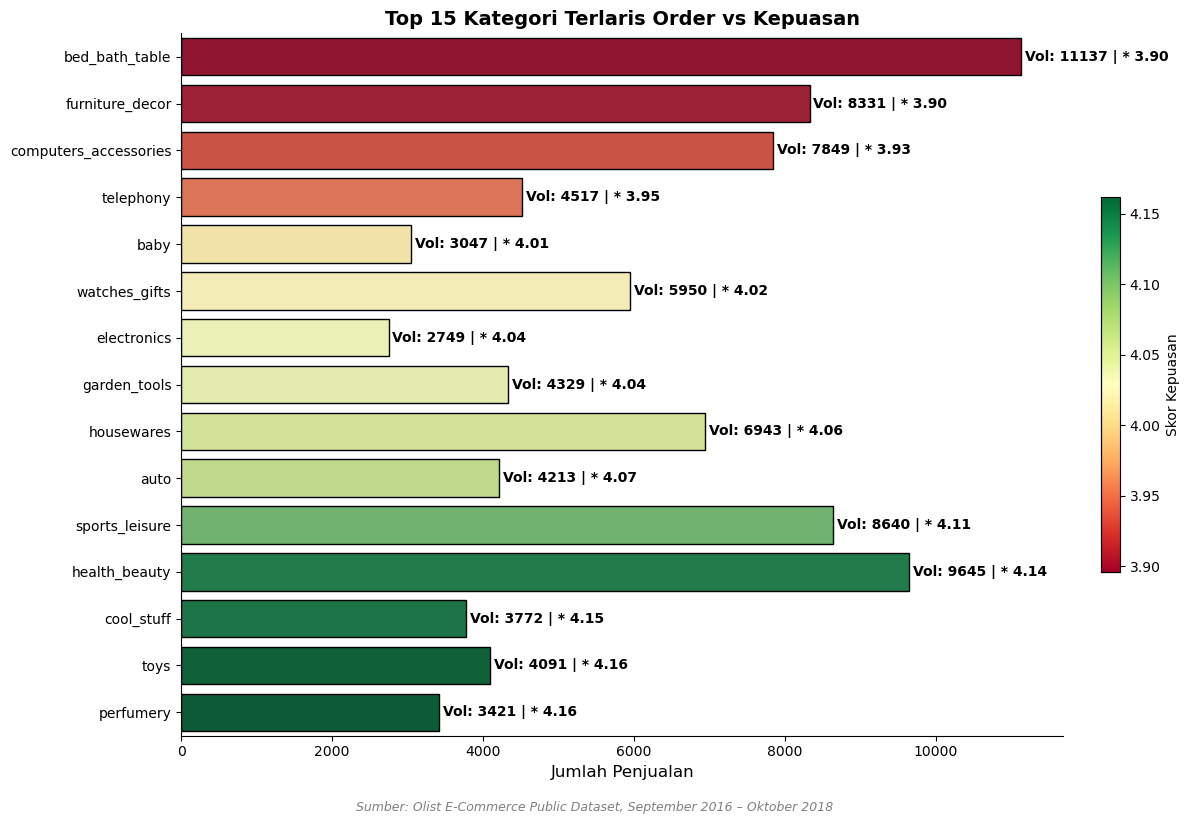

In [63]:
category_data = items_df.merge(product_df, on='product_id') \
                        .merge(reviews_df, on='order_id') \
                        .merge(category_df, on='product_category_name')

agg_cat = category_data.groupby('product_category_name_english').agg({
    'order_id': 'count',
    'review_score': 'mean'})

top_15 = agg_cat.nlargest(15, 'order_id').sort_values('review_score')

plt.figure(figsize=(12, 8))
norm = plt.Normalize(top_15['review_score'].min(), top_15['review_score'].max())
sm = plt.cm.ScalarMappable(cmap="RdYlGn", norm=norm)
colors = [sm.to_rgba(x) for x in top_15['review_score']]

ax = sns.barplot(
    data=top_15, 
    x='order_id', 
    y='product_category_name_english', 
    palette=colors,
    edgecolor='black'
)
i
for i, (vol, rate) in enumerate(zip(top_15['order_id'], top_15['review_score'])):
    plt.text(vol + 50, i, f'Vol: {vol} | * {rate:.2f}', va='center', fontweight='bold')

cbar = plt.colorbar(sm, ax=ax, orientation='vertical', fraction=0.02, pad=0.04)
cbar.set_label('Skor Kepuasan', fontsize=10)

plt.title('Top 15 Kategori Terlaris Order vs Kepuasan', fontsize=14, fontweight='bold')
plt.xlabel('Jumlah Penjualan', fontsize=12)
plt.ylabel('')
sns.despine()

plt.tight_layout()
fig = plt.gcf()
fig.text(0.5, -0.02, 'Sumber: Olist E-Commerce Public Dataset, September 2016 – Oktober 2018', 
         ha='center', fontsize=9, style='italic', color='gray')

plt.show()

### **Insight:**
Grafik ini memberikan perbandingan langsung antara seberapa laku sebuah kategori dengan seberapa puas pelanggan terhadapnya.

1. Identifikasi Area Kritis (Merah):
- Kategori yang berada di posisi atas yang diurutkan berdasarkan rating terendah dan memiliki bar yang menonjol atau penjualan yang banyak merupakan masalah utama.
- Meskipun kategori ini menyumbang ribuan transaksi, skor ratingnya berada di zona merah. Dalam skala E-commerce, rating di bawah 4.0 untuk kategori massal sering dianggap sebagai sinyal adanya masalah operasional sistemik.

2. Kesenjangan Ekspektasi (Warna Kuning/Oranye):
- Kategori di tengah grafik menunjukkan tingkat kepuasan "rata-rata". Penjualan tinggi di sini menunjukkan stabilitas namun ada ruang besar untuk peningkatan layanan agar bisa bergerak ke zona hijau.

3. Gold Standard (Hijau):
- Kategori terlaris yang tetap berwarna hijau pekat adalah model bisnis yang paling sehat. Mereka berhasil menjaga kualitas produk dan ketepatan pengiriman meskipun menangani volume pesanan yang sangat besar.

In [64]:
cus_df.to_csv("data/data clean/customers_clean.csv", index=False)
geo_df.to_csv("data/data clean/geolocation_clean.csv", index=False)
items_df.to_csv("data/data clean/items_clean.csv", index=False)
pay_df.to_csv("data/data clean/payments_clean.csv", index=False)
reviews_df.to_csv("data/data clean/reviews_clean.csv", index=False)
order_df.to_csv("data/data clean/orders_clean.csv", index=False)
category_df.to_csv("data/data clean/category_clean.csv", index=False)
product_df.to_csv("data/data clean/products_clean.csv", index=False)
seller_df.to_csv("data/data clean/seller_clean.csv", index=False)
print("Semua file terpisah berhasil disimpan!")

Semua file terpisah berhasil disimpan!


## Analisis Lanjutan (Opsional)

#### Geospatial Analysis

In [65]:
geo_analysis = order_df.merge(reviews_df, on='order_id') \
                        .merge(items_df, on='order_id') \
                        .merge(cus_df, on='customer_id')
state_stats = geo_analysis.groupby('customer_state').agg({
    'price': 'sum',
    'review_score': 'mean',
    'order_id': 'count'
}).reset_index()

In [66]:
state_coords = geo_df.groupby('geolocation_state')[['geolocation_lat', 'geolocation_lng']].mean().reset_index()
final_geo_data = state_stats.merge(state_coords, left_on='customer_state', right_on='geolocation_state')
m = folium.Map(location=[-14.2350, -51.9253], zoom_start=4, tiles='CartoDB dark_matter')

In [67]:
def get_color(score):
    if score < 3.9:
        return '#FF4500'
    elif score < 4.2:
        return '#FFD700'
    else:
        return '#32CD32'

In [68]:
for i, row in final_geo_data.iterrows():
    popup_text = f"""
    <div style="width: 200px;">
        <h4><b>State: {row['customer_state']}</b></h4>
        <hr>
        <b>Total Revenue:</b> {row['price']:,.0f} BRL<br>
        <b>Avg Rating:</b> {row['review_score']:.2f} / 5.0<br>
        <b>Total Orders:</b> {row['order_id']:,}
    </div>
    """
    folium.CircleMarker(
        location=[row['geolocation_lat'], row['geolocation_lng']],
        radius=row['price'] / 50000,
        color=get_color(row['review_score']),
        fill=True,
        fill_color=get_color(row['review_score']),
        fill_opacity=0.7,
        popup=folium.Popup(popup_text, max_width=300),
        tooltip=f"{row['customer_state']}: Rating {row['review_score']:.2f}" 
    ).add_to(m)

In [69]:
legend_html = '''
     <div style="position: fixed; 
     bottom: 50px; left: 50px; width: 160px; height: 120px; 
     border:2px solid grey; z-index:9999; font-size:14px;
     background-color:white; opacity:0.9; padding: 10px;">
     <b>Kualitas Layanan</b><br>
     <i class="fa fa-circle" style="color:#32CD32"></i> Tinggi (> 4.2)<br>
     <i class="fa fa-circle" style="color:#FFD700"></i> Sedang (3.9 - 4.2)<br>
     <i class="fa fa-circle" style="color:#FF4500"></i> Rendah (< 3.9)<br>
     <br>
     *Ukuran = Total Revenue
     </div>
     '''
m.get_root().html.add_child(folium.Element(legend_html))
m

#### RFM Analysis

**Tujuan:** Mengelompokkan pelanggan berdasarkan perilaku pembelian mereka menggunakan tiga metrik utama:
- **Recency (R):** Berapa hari sejak terakhir kali pelanggan melakukan pembelian
- **Frequency (F):** Berapa total transaksi yang dilakukan pelanggan
- **Monetary (M):** Berapa total pengeluaran pelanggan

Analisis ini membantu mengidentifikasi segmen pelanggan seperti *Best Customers*, *Loyal Customers*, *At-Risk Customers*, dan *Lost Customers* tanpa menggunakan algoritma machine learning.


In [70]:
# RFM Analysis

rfm_data = order_df.merge(items_df, on='order_id', how='inner') \
                   .merge(cus_df, on='customer_id', how='inner')
rfm_data['order_purchase_timestamp'] = pd.to_datetime(rfm_data['order_purchase_timestamp'])
reference_date = rfm_data['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print(f"Tanggal referensi: {reference_date}")
rfm_df = rfm_data.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (reference_date - x.max()).days,
    'order_id': 'nunique', 
    'price': 'sum'
}).reset_index()
rfm_df.columns = ['customer_unique_id', 'Recency', 'Frequency', 'Monetary']
print(f"Jumlah pelanggan unik: {rfm_df.shape[0]:,}")
rfm_df.describe()


Tanggal referensi: 2018-08-30 15:00:37
Jumlah pelanggan unik: 93,336


,Recency,Frequency,Monetary
count,93336.000000,93336.000000,93336.000000
mean,237.903853,1.033417,141.621663
std,152.552964,0.209098,215.714143
min,1.000000,1.000000,0.850000
25%,114.000000,1.000000,47.650000
50%,219.000000,1.000000,89.700000
75%,346.000000,1.000000,154.692500
max,714.000000,15.000000,13440.000000


In [71]:
# Segmentasi RFM menggunakan Binning

rfm_df['R_Score'] = pd.qcut(rfm_df['Recency'], q=4, labels=[4, 3, 2, 1])
rfm_df['F_Score'] = rfm_df['Frequency'].apply(lambda x: 4 if x >= 4 else (3 if x >= 3 else (2 if x >= 2 else 1)))
rfm_df['M_Score'] = pd.qcut(rfm_df['Monetary'], q=4, labels=[1, 2, 3, 4])
rfm_df['RFM_Score'] = rfm_df['R_Score'].astype(str) + rfm_df['F_Score'].astype(str) + rfm_df['M_Score'].astype(str)
rfm_df.head(10)

,customer_unique_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,129.90,4,1,3,413
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,18.90,3,1,1,311
2,0000f46a3911fa3c0805444483337064,537,1,69.00,1,1,2,112
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,25.99,2,1,1,211
4,0004aac84e0df4da2b147fca70cf8255,288,1,180.00,2,1,4,214
5,0004bd2a26a76fe21f786e4fbd80607f,146,1,154.00,3,1,3,313
6,00050ab1314c0e55a6ca13cf7181fecf,132,1,27.99,3,1,1,311
7,00053a61a98854899e70ed204dd4bafe,183,1,382.00,3,1,4,314
8,0005e1862207bf6ccc02e4228effd9a0,543,1,135.00,1,1,3,113
9,0005ef4cd20d2893f0d9fbd94d3c0d97,170,1,104.90,3,1,3,313


In [72]:
# Segmentasi Pelanggan berdasarkan Skor RFM

def rfm_segment(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    m = int(row['M_Score'])
    total = r + f + m
    
    if r >= 3 and f >= 3 and m >= 3:
        return 'Best Customers'
    elif r >= 3 and f >= 2:
        return 'Loyal Customers'
    elif r >= 3:
        return 'New Customers'
    elif r >= 2 and f >= 2:
        return 'At Risk'
    elif r == 1 and f >= 2:
        return 'Cant Lose Them'
    else:
        return 'Lost Customers'

rfm_df['Segment'] = rfm_df.apply(rfm_segment, axis=1)
segment_counts = rfm_df['Segment'].value_counts()
print("Distribusi Segmen Pelanggan:")
print(segment_counts)
print(f"\nPersentase:")
print((segment_counts / segment_counts.sum() * 100).round(1))

Distribusi Segmen Pelanggan:
Segment
New Customers      45292
Lost Customers     45244
Loyal Customers     1413
At Risk              672
Cant Lose Them       579
Best Customers       136
Name: count, dtype: int64

Persentase:
Segment
New Customers      48.5
Lost Customers     48.5
Loyal Customers     1.5
At Risk             0.7
Cant Lose Them      0.6
Best Customers      0.1
Name: count, dtype: float64


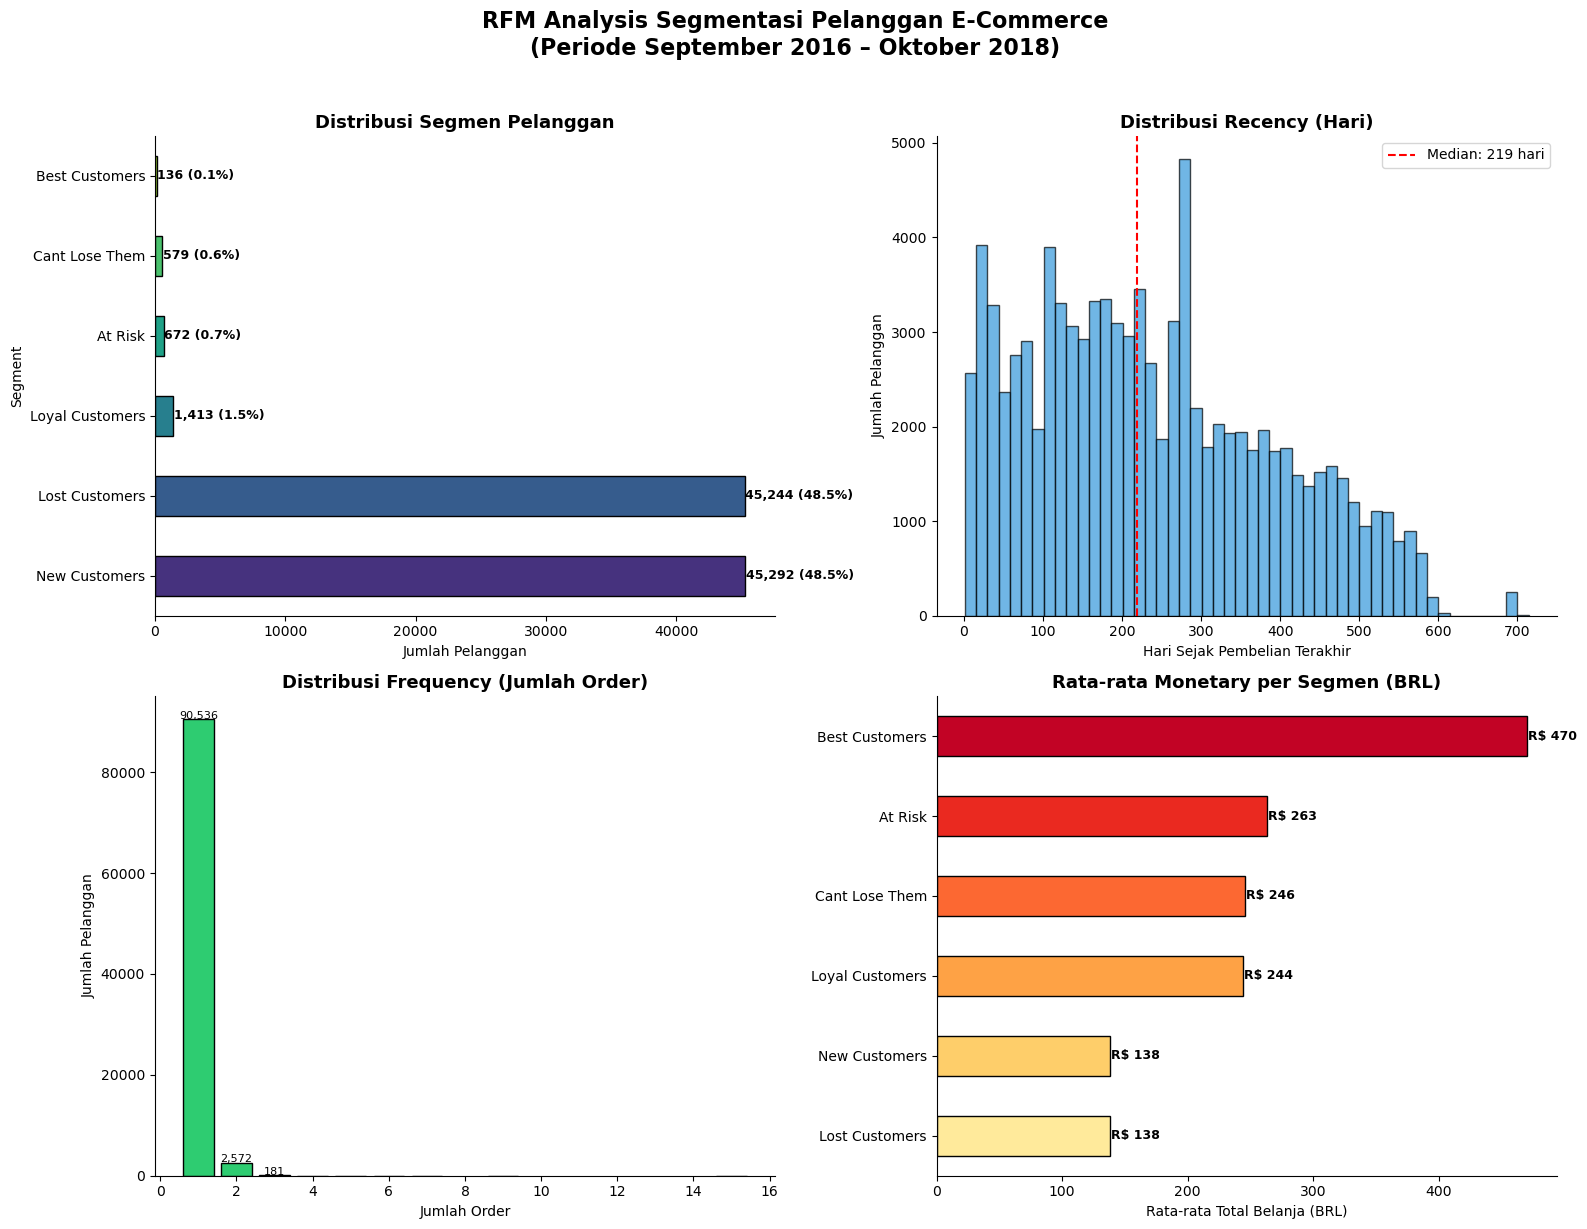

In [73]:
# Visualisasi RFM

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('RFM Analysis Segmentasi Pelanggan E-Commerce\n(Periode September 2016 – Oktober 2018)', 
             fontsize=16, fontweight='bold', y=1.02)

colors_seg = sns.color_palette('viridis', n_colors=len(segment_counts))
segment_counts.plot(kind='barh', ax=axes[0, 0], color=colors_seg, edgecolor='black')
axes[0, 0].set_title('Distribusi Segmen Pelanggan', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Jumlah Pelanggan')
for idx, val in enumerate(segment_counts.values):
    axes[0, 0].text(val + 50, idx, f'{val:,} ({val/segment_counts.sum()*100:.1f}%)', 
                    va='center', fontweight='bold', fontsize=9)

axes[0, 1].hist(rfm_df['Recency'], bins=50, color='#3498db', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Distribusi Recency (Hari)', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Hari Sejak Pembelian Terakhir')
axes[0, 1].set_ylabel('Jumlah Pelanggan')
axes[0, 1].axvline(rfm_df['Recency'].median(), color='red', linestyle='--', label=f'Median: {rfm_df["Recency"].median():.0f} hari')
axes[0, 1].legend()


freq_counts = rfm_df['Frequency'].value_counts().sort_index()
axes[1, 0].bar(freq_counts.index, freq_counts.values, color='#2ecc71', edgecolor='black')
axes[1, 0].set_title('Distribusi Frequency (Jumlah Order)', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Jumlah Order')
axes[1, 0].set_ylabel('Jumlah Pelanggan')
for idx, val in zip(freq_counts.index, freq_counts.values):
    if val > 100:
        axes[1, 0].text(idx, val + 50, f'{val:,}', ha='center', fontsize=8)

seg_monetary = rfm_df.groupby('Segment')['Monetary'].mean().sort_values(ascending=True)
seg_monetary.plot(kind='barh', ax=axes[1, 1], color=sns.color_palette('YlOrRd', n_colors=len(seg_monetary)), edgecolor='black')
axes[1, 1].set_title('Rata-rata Monetary per Segmen (BRL)', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Rata-rata Total Belanja (BRL)')
axes[1, 1].set_ylabel('')
for idx, val in enumerate(seg_monetary.values):
    axes[1, 1].text(val + 1, idx, f'R$ {val:,.0f}', va='center', fontsize=9, fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

### **Insight RFM Analysis:**

1. **Mayoritas pelanggan termasuk segmen "Lost Customers" atau "New Customers"**. Hal ini menunjukkan bahwa sebagian besar pelanggan hanya melakukan 1 kali transaksi dan tidak kembali. Tingkat *repeat purchase* sangat rendah.

2. **Segmen "Best Customers" sangat kecil**. Pelanggan yang memiliki Recency rendah, Frequency tinggi, DAN Monetary tinggi hanya segelintir. Ini adalah pelanggan paling berharga yang harus dijaga.

3. **Segmen "Cant Lose Them"**. Menunjukkan pelanggan yang dulunya aktif dan bernilai tinggi atau Frequency dan Monetary tinggi tetapi sudah lama tidak belanja atau Recency tinggi. Segmen ini perlu ditargetkan dengan kampanye re-engagement.

4. **Rata-rata Monetary tertinggi** ada di segmen "Best Customers" dan "Cant Lose Them", mengkonfirmasi bahwa kedua segmen ini memiliki nilai bisnis yang kritis.


#### Clustering Manual Grouping & Binning

**Tujuan:** Mengelompokkan data ke dalam kategori bermakna menggunakan teknik binning dan manual grouping berdasarkan aturan bisnis. Teknik ini membantu mengidentifikasi pola tanpa menggunakan algoritma machine learning.


In [74]:
# Segmentasi Produk berdasarkan Harga

product_price = items_df.merge(product_df, on='product_id') \
                        .merge(category_df, on='product_category_name', how='left')
bins = [0, 50, 150, 500, float('inf')]
labels = ['Budget (0-50 BRL)', 'Mid-Range (50-150 BRL)', 'Premium (150-500 BRL)', 'Luxury (500+ BRL)']
product_price['price_segment'] = pd.cut(product_price['price'], bins=bins, labels=labels)
segment_dist = product_price['price_segment'].value_counts().sort_index()
print("Distribusi Segmen Harga Produk:")
print(segment_dist)
print(f"\nPersentase:")
print((segment_dist / segment_dist.sum() * 100).round(1))

Distribusi Segmen Harga Produk:
price_segment
Budget (0-50 BRL)         38661
Mid-Range (50-150 BRL)    50188
Premium (150-500 BRL)     19011
Luxury (500+ BRL)          3186
Name: count, dtype: int64

Persentase:
price_segment
Budget (0-50 BRL)         34.8
Mid-Range (50-150 BRL)    45.2
Premium (150-500 BRL)     17.1
Luxury (500+ BRL)          2.9
Name: count, dtype: float64


In [75]:
# Analisis Performa per Segmen Harga

product_cluster = product_price.merge(reviews_df[['order_id', 'review_score']], on='order_id', how='inner')
cluster_stats = product_cluster.groupby('price_segment', observed=True).agg({
    'order_id': 'count',
    'review_score': 'mean',
    'price': 'mean',
    'freight_value': 'mean'
}).reset_index()
cluster_stats.columns = ['Segmen Harga', 'Jumlah Order', 'Rata-rata Rating', 'Rata-rata Harga', 'Rata-rata Ongkir']
cluster_stats['Rasio Ongkir/Harga (%)'] = (cluster_stats['Rata-rata Ongkir'] / cluster_stats['Rata-rata Harga'] * 100).round(1)
cluster_stats

,Segmen Harga,Jumlah Order,Rata-rata Rating,Rata-rata Harga,Rata-rata Ongkir,Rasio Ongkir/Harga (%)
0,Budget (0-50 BRL),38597,4.035754,31.449827,14.766671,47.0
1,Mid-Range (50-150 BRL),50082,4.033705,92.927215,19.482365,21.0
2,Premium (150-500 BRL),18939,4.043508,241.163237,27.527760,11.4
3,Luxury (500+ BRL),3155,4.003170,922.669715,47.476662,5.1


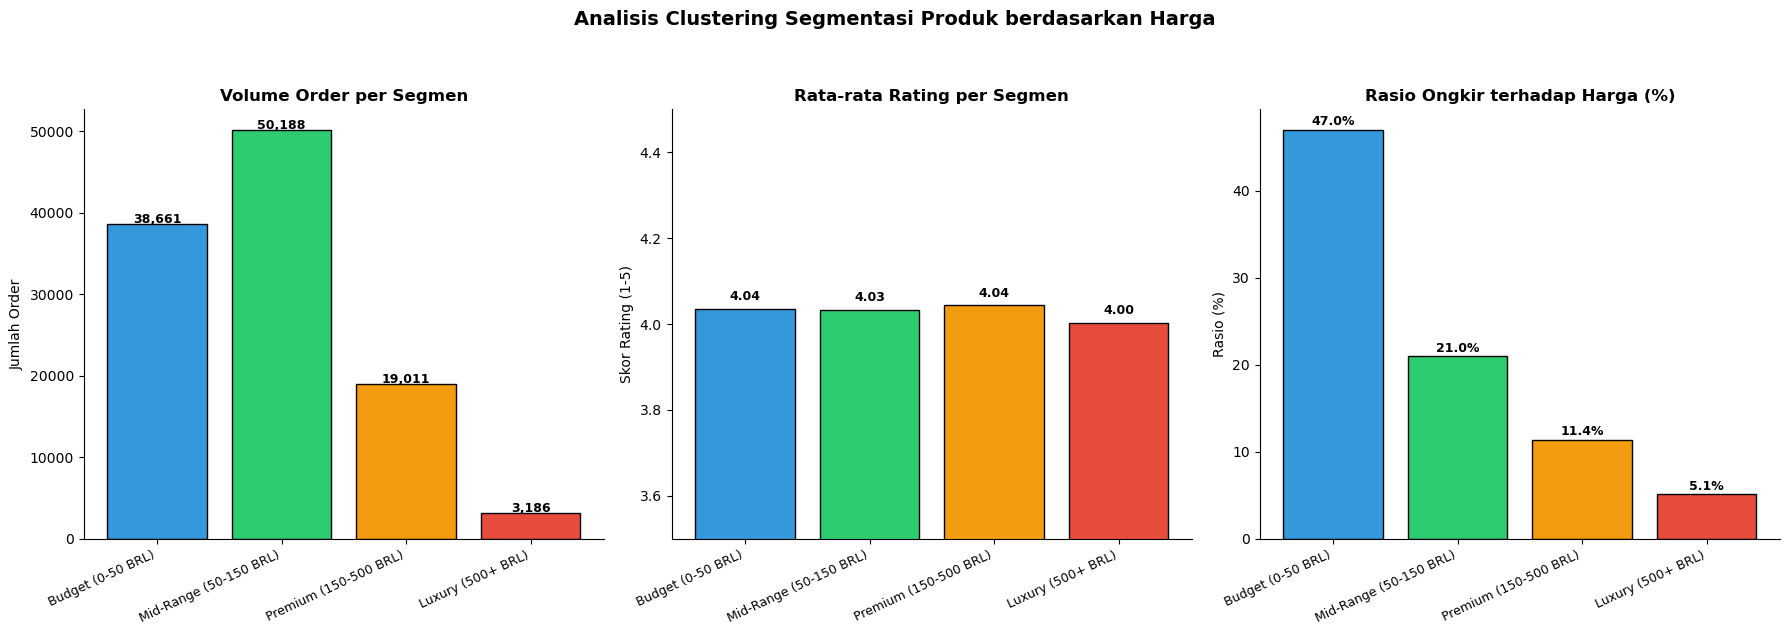

In [76]:
# Visualisasi Clustering

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Analisis Clustering Segmentasi Produk berdasarkan Harga', 
             fontsize=14, fontweight='bold', y=1.05)

colors_cluster = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']

axes[0].bar(range(len(segment_dist)), segment_dist.values, color=colors_cluster, edgecolor='black')
axes[0].set_xticks(range(len(segment_dist)))
axes[0].set_xticklabels(segment_dist.index, rotation=25, ha='right', fontsize=9)
axes[0].set_title('Volume Order per Segmen', fontweight='bold')
axes[0].set_ylabel('Jumlah Order')
for idx, val in enumerate(segment_dist.values):
    axes[0].text(idx, val + 100, f'{val:,}', ha='center', fontweight='bold', fontsize=9)

axes[1].bar(range(len(cluster_stats)), cluster_stats['Rata-rata Rating'], color=colors_cluster, edgecolor='black')
axes[1].set_xticks(range(len(cluster_stats)))
axes[1].set_xticklabels(cluster_stats['Segmen Harga'], rotation=25, ha='right', fontsize=9)
axes[1].set_title('Rata-rata Rating per Segmen', fontweight='bold')
axes[1].set_ylabel('Skor Rating (1-5)')
axes[1].set_ylim(3.5, 4.5)
for idx, val in enumerate(cluster_stats['Rata-rata Rating']):
    axes[1].text(idx, val + 0.02, f'{val:.2f}', ha='center', fontweight='bold', fontsize=9)

axes[2].bar(range(len(cluster_stats)), cluster_stats['Rasio Ongkir/Harga (%)'], color=colors_cluster, edgecolor='black')
axes[2].set_xticks(range(len(cluster_stats)))
axes[2].set_xticklabels(cluster_stats['Segmen Harga'], rotation=25, ha='right', fontsize=9)
axes[2].set_title('Rasio Ongkir terhadap Harga (%)', fontweight='bold')
axes[2].set_ylabel('Rasio (%)')
for idx, val in enumerate(cluster_stats['Rasio Ongkir/Harga (%)']):
    axes[2].text(idx, val + 0.5, f'{val}%', ha='center', fontweight='bold', fontsize=9)

sns.despine()
plt.tight_layout()
plt.show()

### **Insight Clustering:**

1. **Segmen Budget (0-50 BRL) mendominasi** volume transaksi, menunjukkan bahwa marketplace ini didominasi oleh produk-produk murah.

2. **Rasio ongkir terhadap harga sangat timpang di segmen Budget**. Produk murah memiliki rasio ongkir/harga yang sangat tinggi, artinya pelanggan membayar ongkir yang proporsinya hampir setara atau melebihi harga produk. Ini menjadi sumber ketidakpuasan utama.

3. **Segmen Premium dan Luxury memiliki rasio ongkir/harga yang lebih wajar**, namun jumlah transaksinya jauh lebih kecil.

4. **Rekomendasi:** Platform sebaiknya mempertimbangkan subsidi ongkir untuk produk Budget guna meningkatkan kepuasan pelanggan, atau menerapkan minimum order untuk mengoptimalkan biaya logistik.


## Conclusion

- Conclution pertanyaan 1

`Apakah keterlambatan pengiriman berkorelasi langsung dengan rendahnya review_score?`

Ya, berkorelasi sangat kuat. Data membuktikan bahwa keterlambatan terhadap estimasi adalah prediktor utama munculnya Bintang 1. Pelanggan jauh lebih toleran terhadap durasi pengiriman yang lama asalkan barang sampai sebelum atau tepat pada tanggal estimasi. Kegagalan memenuhi estimasi (Delta > 0) hampir selalu berujung pada komplain dan rating rendah.

`Wilayah mana yang memiliki performa pengiriman terburuk?`

Wilayah Utara Brazil adalah yang terburuk, dengan RR (Roraima) sebagai negara bagian dengan durasi pengiriman terlama. Hal ini kemungkinan besar disebabkan oleh jarak geografis dari hub penjual yang mayoritas berada di wilayah Tenggara (Sao Paulo/Rio de Janeiro).

- Conclution pertanyaan 2

`Kategori produk apa yang memiliki volume penjualan tinggi tetapi tingkat kepuasan rendah?`

1. bed_bath_table
2. furniture_decor
3. computer_accessories

`Analisis Mengapa Hal Ini Terjadi?`

- Produk kategori Furniture dan Bed & Bath seringkali memiliki dimensi yang besar dan berat. Hal ini meningkatkan risiko kerusakan saat pengiriman dan keterlambatan pengiriman, yang sebelumnya telah kita buktikan berkorelasi kuat dengan Bintang 1.
- Produk dekorasi dan furnitur sangat bergantung pada visual. Ketidaksesuaian antara foto di platform dengan barang asli saat sampai memicu kekecewaan pelanggan.
- Karena volumenya sangat masif (ribuan order per bulan), pengawasan kualitas dari sisi seller menjadi lebih sulit dijaga dibandingkan kategori hobi yang volumenya kecil namun personal.

## Rekomendasi Action Items

Berdasarkan seluruh analisis yang telah dilakukan, berikut adalah rekomendasi tindakan konkret yang dapat diambil:

### Berdasarkan Pertanyaan 1

1. **Kalibrasi ulang estimasi waktu pengiriman** untuk wilayah Utara Brazil (RR, AP, AM) dengan menambahkan *buffer* 5-7 hari. Data menunjukkan bahwa pelanggan lebih toleran terhadap pengiriman lama asalkan sesuai estimasi. Mengurangi *delivery delta positif* akan langsung meningkatkan skor review.

2. **Prioritaskan pembangunan hub distribusi satelit** di wilayah Utara/Timur Laut Brazil. Rata-rata durasi pengiriman 25-30 hari di wilayah ini secara signifikan menekan rating keseluruhan platform.

3. **Implementasi sistem notifikasi proaktif** yang menginformasikan pelanggan ketika pengiriman diprediksi melebihi estimasi. Komunikasi proaktif terbukti mampu meredam ketidakpuasan.

### Berdasarkan Pertanyaan 2

4. **Terapkan *Quality Control* ketat** untuk kategori bed_bath_table, furniture_decor, dan computer_accessories tiga kategori terlaris dengan rating terendah. Wajibkan seller di kategori ini untuk mengunggah foto produk beresolusi tinggi dari minimal 3 sudut.

5. **Gunakan *packaging* khusus bertuliskan "FRAGILE"** untuk produk furnitur dan dekorasi berukuran besar, karena kerusakan saat pengiriman merupakan faktor utama rating rendah.

### Berdasarkan Analisis Lanjutan RFM & Clustering

6. **Jalankan kampanye re-engagement** untuk segmen "Cant Lose Them" yang dulunya aktif tapi sudah lama tidak belanja. Tawarkan voucher diskon personal berdasarkan kategori favorit mereka.

7. **Subsidi ongkir untuk segmen Budget (0-50 BRL)** atau terapkan *minimum order value* untuk efisiensi logistik. Rasio ongkir/harga yang tinggi di segmen ini menjadi penghambat utama kepuasan pelanggan.
